# Importing Libraries

In [ ]:
!pip install emoji
!pip install pyspellchecker
!pip install pyspellchecker==0.7.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.9/586.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 28.1 MB/s eta 0:00:00
  Attempting uninstall: pyspellchecker
    Found existing installation: pyspellchecker 0.8.2
    Uninstalling pyspellchecker-0.8.2:
      Successfully uninstalled pyspellchecker-0.8.2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
%matplotlib inline
import nltk
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

downloading toolkits

---



In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

reading the dataset from csv

---



In [ ]:
twitter_data = pd.read_csv('Twitter_Data.csv')
reddit_data = pd.read_csv('Reddit_Data.csv')

# Merging Dataframes

Merging 'twitter, reddit' data

---



In [ ]:
data = pd.concat([twitter_data, reddit_data], ignore_index = True)

In [ ]:
data

,messages,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
200285,Her sarcasm can really kill a conversation.,-1.0
200286,The heat can kill if you're not careful.,-1.0
200287,She was determined to kill it at her performance.,-1.0
200288,The new law aims to kill illegal trade.,-1.0


In [ ]:
data.tail()

,messages,labels
200285,Her sarcasm can really kill a conversation.,-1.0
200286,The heat can kill if you're not careful.,-1.0
200287,She was determined to kill it at her performance.,-1.0
200288,The new law aims to kill illegal trade.,-1.0
200289,He asked her to kill the engine before leaving...,-1.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200290 entries, 0 to 200289
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   messages  200186 non-null  object 
 1   labels    200283 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.1+ MB


#Data Pre-Processing

Handling Missing Value

---



In [ ]:
data.isnull().sum()

,0
messages,104
labels,7


Dropping Missing value

---



In [ ]:
data = data.dropna()

In [ ]:
data.isnull().sum()

,0
messages,0
labels,0


In [ ]:
data.head()

,messages,labels
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
data.tail()

,messages,labels
200285,Her sarcasm can really kill a conversation.,-1.0
200286,The heat can kill if you're not careful.,-1.0
200287,She was determined to kill it at her performance.,-1.0
200288,The new law aims to kill illegal trade.,-1.0
200289,He asked her to kill the engine before leaving...,-1.0


In [ ]:
data['labels'].value_counts()

,count
labels,
1.0,88079
0.0,68253
-1.0,43847


Jumble data

---



In [ ]:
data = data.sample(frac=1)

0  - Indicating it is a Neutral Tweet/Comment

1  - Indicating a Postive Sentiment

-1 - Indicating a Negative Tweet/Comment

---



# Stemming and Cleaning the Data

Libraries of NLTK


---



In [ ]:
import re,string,nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer
from spellchecker import SpellChecker
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

cleaning the data from unnecessary data

---



In [ ]:
#replacing url with string URL
def replace_url(text):
  return re.sub('https?:\/\/\S*|www\.\S+','URL',text)

In [ ]:
#removing html
def remove_html(text):
    return re.sub('<.*?>','',text)

In [ ]:
#replacing mentions with string user
def replace_mentions(text):
    return re.sub('@\S*','user',text,flags=re.IGNORECASE)

In [ ]:
#replacing numbers with string number
def replace_num(text):
    return re.sub('^[+-]*?\d{1,3}[- ]*?\d{1,10}|\d{10}','NUMBER',text)

In [ ]:
#replacing <3 with sring heart
def replace_heart(text):
    return re.sub('<3','HEART', text)

In [ ]:
#removing alphanumeric characters eg-XYZ123ABC
def remove_alphanumeric(text):
    return re.sub('\w*\d+\w*','',text)

In [ ]:
#removing all english stopwords
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in stopwords.words("english")])
    return text

In [ ]:
#removing punctuations
def remove_punctuations(text):
    text=''.join([word for word in text if word not in string.punctuation])
    return text

In [ ]:
#reducing words to thier root form
def lemmatization(text):
    lm= WordNetLemmatizer()
    text = ' '.join([lm.lemmatize(word, pos='v') for word in text.split()])
    return text

In [ ]:
# Handling of Negation Words
negation_words = ['not', 'never', 'no', 'don\'t', 'doesn\'t', 'can\'t', 'won\'t', 'shouldn\'t', 'couldn\'t', 'wouldn\'t']

def handle_negations(text):
  words = text.split()
  negated = False
  modified_words = []
  for word in words:
    if word in negation_words:
      negated = True
    elif negated:
      word = 'NOT_' + word
      negated = False
    modified_words.append(word)
  return " ".join(modified_words)

In [ ]:
#replace expression to word
def replace_expressions(text):
    # Laughter
    text = re.sub(r'(ha|he|hi|ho|hu){3,}', 'laugh', text)
    text = re.sub(r'(lmao|lmfao)', 'laugh', text)
    # Crying
    text = re.sub(r'(hu|ho|uh|sob){3,}', 'cry', text)
    text = re.sub(r'(t_t|;-;|:’\(|:’\))', 'cry', text)
    # Surprise/Shock
    text = re.sub(r'(wow+|omg+|whoa+)', 'surprise', text)
    text = re.sub(r'(:o|:0|O_O|o_o|O_o)', 'surprise', text)
    # Anger/Frustration
    text = re.sub(r'(argh+|grr+|ugh+)', 'anger', text)
    text = re.sub(r'(>_<|>:o|D:<)', 'anger', text)
    # Love/Excitement
    text = re.sub(r'(aww+|yay+|love+|<3)', 'love', text)
    text = re.sub(r'(\^\^|UwU|OwO)', 'love', text)
    # Confusion
    text = re.sub(r'(huh+|umm+|eh+|what+)', 'confusion', text)
    text = re.sub(r'(:/|:/|\\\\?|\\\\o|\\\\w)', 'confusion', text)
    # Other emotions
    text = re.sub(r'(zzz+|zzzz+)', 'sleepy', text)
    text = re.sub(r'(yay+|woohoo+|hooray+)', 'excitement', text)

    return text

In [ ]:
#convert abbv jargons to original
jargon_dict = {
    'brb': 'be right back',
    'lol': 'laughing out loud',
    'rofl': 'rolling on the floor laughing',
    'idk': 'I don’t know',
    'btw': 'by the way',
    'imo': 'in my opinion',
    'imho': 'in my humble opinion',
    'nvm': 'never mind',
    'tbh': 'to be honest',
    'ikr': 'I know, right?',
    'smh': 'shaking my head',
    'fyi': 'for your information',
    'omg': 'oh my God',
    'ttyl': 'talk to you later',
    'bff': 'best friends forever',
    'afk': 'away from keyboard',
    'g2g': 'got to go',
    'np': 'no problem',
    'asap': 'as soon as possible',
    'lmk': 'let me know',
    'wfh': 'working from home',
    'tbt': 'throwback Thursday',
    'hmu': 'hit me up',
    'yw': 'you’re welcome',
    'gg': 'good game',
    'wp': 'well played',
    'omw': 'on my way',
    'ftw': 'for the win',
    'jk': 'just kidding',
    'wtf': 'what the fudge',
    'wyd': 'what you doing',
    'sus': 'suspicious',
    'dm': 'direct message',
    'faq': 'frequently asked questions',
    'irl': 'in real life',
    'afaik': 'as far as I know',
    'bruh': 'brother',
    'bday': 'birthday',
    'tho': 'though',
    'rn': 'right now',
    'plz': 'please',
    'btw': 'by the way',
    'ty': 'thank you',
    'ily': 'I love you',
    'tysm': 'thank you so much'
}

def replace_jargon(text):
    words = text.split()
    replaced_words = [jargon_dict.get(word.lower(), word) for word in words]
    return " ".join(replaced_words)

Applying the cleaning proccess

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = replace_url(text)
    text = remove_html(text)
    text = replace_mentions(text)
    text = replace_num(text)
    text = replace_heart(text)
    text = remove_alphanumeric(text)
    text = replace_expressions(text)
    text = replace_jargon(text)
    text = remove_stopwords(text)
    text = remove_punctuations(text)
    text = handle_negations(text)
    text = lemmatization(text)
    return text

clean_text to every item in the messages column of the data and storing to message1

In [ ]:
data['messages1']=data['messages'].apply(clean_text)

In [ ]:
data['messages1']

,messages1
117648,dont worry modi aayga
7187,confusion wrong modi remain till fit
153192,modi go state party finish precious lok sabha ...
143320,don’ find decent job wait modi achieve forty f...
156252,modi modi alone take decision purchase rafale ...
...,...
15840,advanis present modis future dig grind
9353,persons wudnt vote modi mullahshad vote pidisw...
38870,choice leave want skill india vote modi want k...
105331,sure construction lord rama temple take place ...


#Sentiment Analysis

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer


sid = SentimentIntensityAnalyzer()


def get_sentiment_scores(text):
    scores = sid.polarity_scores(text)
    compound_score = scores['compound']
    return compound_score

# Apply sentiment analysis to the cleaned text data
data['sentiment_score'] = data['messages1'].apply(get_sentiment_scores)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200179 entries, 117648 to 157651
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   messages         200179 non-null  object 
 1   labels           200179 non-null  float64
 2   messages1        200179 non-null  object 
 3   sentiment_score  200179 non-null  float64
dtypes: float64(2), object(2)
memory usage: 7.6+ MB


In [ ]:
data.drop('messages', axis=1, inplace=True)

In [ ]:
data.head()

,labels,messages1,sentiment_score
117648,0.0,dont worry modi aayga,0.3412
7187,-1.0,confusion wrong modi remain till fit,-0.4215
153192,1.0,modi go state party finish precious lok sabha ...,0.9517
143320,-1.0,don’ find decent job wait modi achieve forty f...,-0.4939
156252,-1.0,modi modi alone take decision purchase rafale ...,-0.1531


# EDA & Visualization

The distribution of sentiments

---



<Axes: xlabel='labels'>

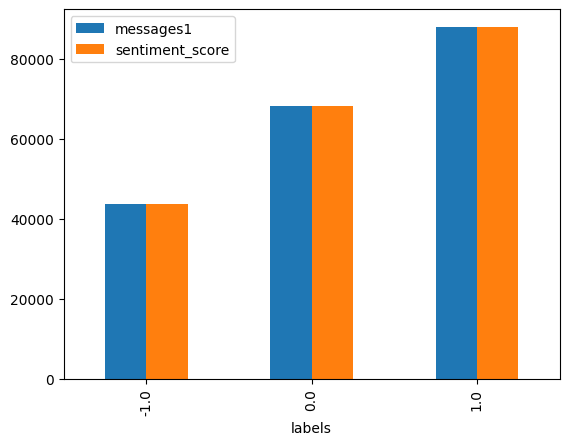

In [ ]:
data.groupby('labels').count().plot(kind='bar')

Pie chart

---



In [ ]:
import plotly.express as px
label_mapping = {
    1: 'Positive',
    0: 'Neutral',
    -1: 'Negative'
}
data['sentiment_name'] = data['labels'].map(label_mapping)
fig = px.pie(data, names='sentiment_name', title='Sentiment Distribution')
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

Output hidden; open in https://colab.research.google.com to view.

Word cloud for frequent words in dataset

---



In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
def wordcount_gen(df, category, sentiment_column='sentiment_score'):

              filtered_data = df[df[sentiment_column] > 0.5] if category == 'Positive' else df[df[sentiment_column] <= 0.5]

              combined_tweets = " ".join(filtered_data['messages1'])

              wc = WordCloud(background_color='black',
                              max_words=50,
                              stopwords=STOPWORDS)
              plt.figure(figsize=(10, 10))
              plt.imshow(wc.generate(combined_tweets))
              plt.title('{} Sentiment Words'.format(category), fontsize=20)
              plt.axis('off')
              plt.show()

POSITIVE

---



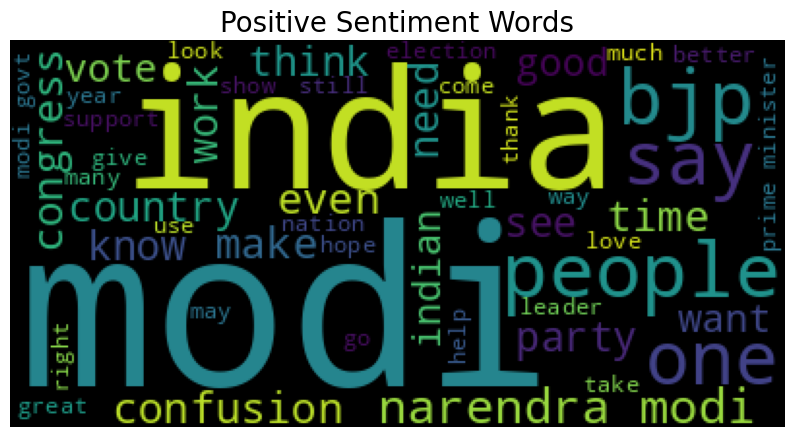

In [ ]:
wordcount_gen(data, 'Positive')

NEGATIVE

---



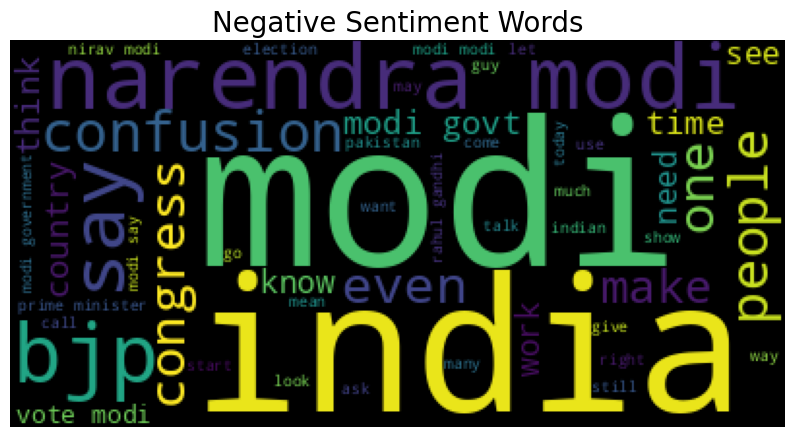

In [ ]:
wordcount_gen(data, 'Negative')

NEUTRAL

---



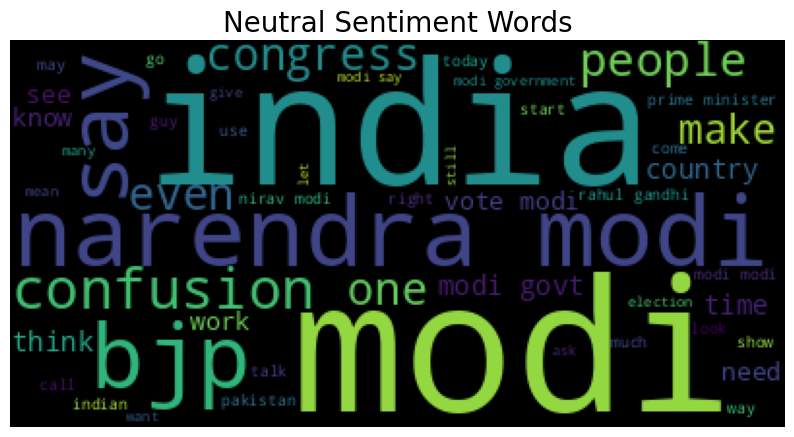

In [ ]:
wordcount_gen(data, 'Neutral')

BAR PLOT OF WORD FREQUENCIES

---



<ipython-input-50-a031d2409f3d>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




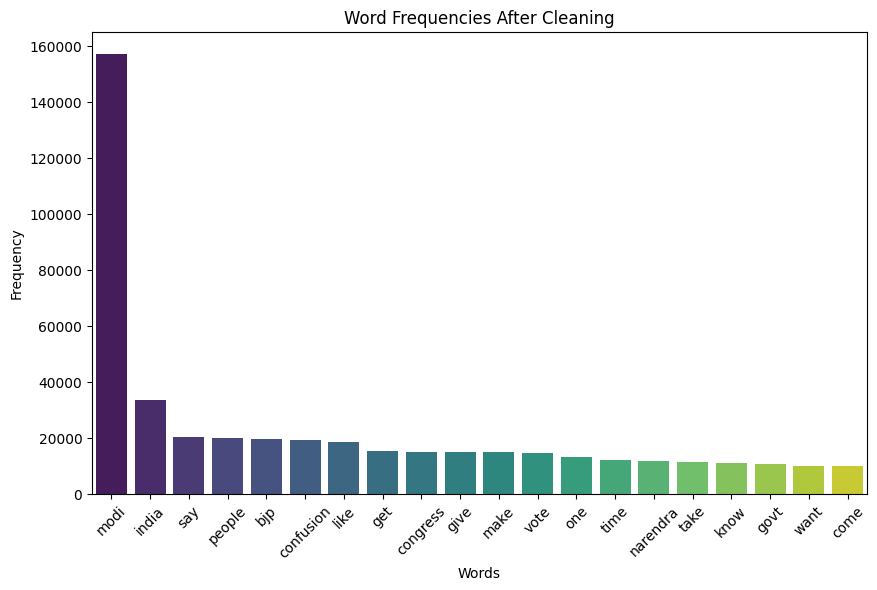

In [ ]:
def plot_word_frequencies(text, title):
    word_freq = nltk.FreqDist(text.split())
    common_words = word_freq.most_common(20)
    words, freqs = zip(*common_words)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(words), y=list(freqs), palette='viridis')
    plt.title(title)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()
# Step 3: Plot bar plots of word frequencies
plot_word_frequencies(' '.join(data['messages1']), 'Word Frequencies After Cleaning')

# Splitting data into Training and Testing

Library

---



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200179 entries, 117648 to 157651
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   labels           200179 non-null  float64
 1   messages1        200179 non-null  object 
 2   sentiment_score  200179 non-null  float64
 3   sentiment_name   200179 non-null  object 
dtypes: float64(2), object(2)
memory usage: 7.6+ MB


Finding X and y

---



In [ ]:
X = data['messages1']
y = data['labels']

Split the data into training and testing sets

---



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

Vectorize text data

---



In [ ]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Training Model - Logistic Regression

library

---



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Initialize logistic regression model
log_reg_model = LogisticRegression(max_iter=10000)

# Train the logistic regression model on the training data
log_reg_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=10000)

Predict on the testing data

---



In [ ]:
y_pred_log_reg = log_reg_model.predict(X_test_tfidf)

# Model Evaluation

In [ ]:
#Calculate accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

Testing Accuracy

---



In [ ]:
log_reg_model.score(X_test_tfidf, y_test)

0.8665201318813068

Training accuracy

---



In [ ]:
log_reg_model.score(X_train_tfidf, y_train)

0.896115141456808

Generate confusion matrix

---



In [ ]:
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("Logistic Regression Confusion Matrix:")
print(conf_matrix_log_reg)

Logistic Regression Confusion Matrix:
[[3258  520  623]
 [ 157 6432  289]
 [ 385  698 7656]]


Generate classification report

In [ ]:
report_log_reg = classification_report(y_test, y_pred_log_reg)
print("Logistic Regression Classification Report:")
print(report_log_reg)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        -1.0       0.86      0.74      0.79      4401
         0.0       0.84      0.94      0.89      6878
         1.0       0.89      0.88      0.88      8739

    accuracy                           0.87     20018
   macro avg       0.86      0.85      0.85     20018
weighted avg       0.87      0.87      0.87     20018



# Deployment

Verifying the model output using vader sent intensity

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
  cleaned_text = clean_text(text)
  text_tfidf = tfidf_vectorizer.transform([cleaned_text])
  prediction = log_reg_model.predict(text_tfidf)[0]

  return prediction

def verify_with_vader(text):
  vader_score = sid.polarity_scores(text)['compound']
  if vader_score >= 0.05:
    return "Positive"
  elif vader_score <= -0.05:
    return "Negative"
  else:
    return "Neutral"

user_input = input("Text to analyze: ")

model_sentiment = analyze_sentiment(user_input)
vader_sentiment = verify_with_vader(user_input)

print("Model Sentiment:", model_sentiment)
print("\nMODEL")
if model_sentiment == 0:
  print("Model Sentiment: Neutral")
elif model_sentiment == 1:
  print("Model Sentiment: Positive")
else:
  print("Model Sentiment: Negative")

print("\nVERIFY")
print("VADER Sentiment for verification:", vader_sentiment)



Text to analyze: oh my God
Model Sentiment: 0.0

MODEL
Model Sentiment: Neutral

VERIFY
VADER Sentiment for verification: Positive


In [ ]:
'''import joblib

joblib.dump(log_reg_model, 'sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')'''

"import joblib\n\njoblib.dump(log_reg_model, 'sentiment_model.pkl')\njoblib.dump(tfidf_vectorizer, 'vectorizer.pkl')"

In [ ]:
'''from google.colab import files
files.download('sentiment_model.pkl')
files.download('vectorizer.pkl')'''


"from google.colab import files\nfiles.download('sentiment_model.pkl')\nfiles.download('vectorizer.pkl')"